# Лаба 1

Да поможет мне господь.

## Задание 1

### Задание 1.1. Синтетический тест: Концентрация меры на сфере $\mathbb{S}^{d-1}$

In [2]:
import numpy
import pandas
import seaborn
import matplotlib.pyplot
import scipy

In [3]:
# Количество векторов.
M = 20000

# Размерности пространств.
D = [16, 64, 256, 512, 4096]
S = [0] * len(D)

In [4]:
for iteration, d in enumerate(D):
    X = numpy.array([
        numpy.random.normal(0.0, 1.0, (d)) for _ in range(M)
    ])
    
    Y = numpy.array([
        numpy.random.normal(0.0, 1.0, (d)) for _ in range(M)
    ])
    
    for i in range(M):
        X[i] /= numpy.linalg.norm(X[i])
        Y[i] /= numpy.linalg.norm(Y[i])

    s = numpy.zeros(M)

    for i in range(M):
        s[i] = numpy.dot(X[i], Y[i])

    S[iteration] = s

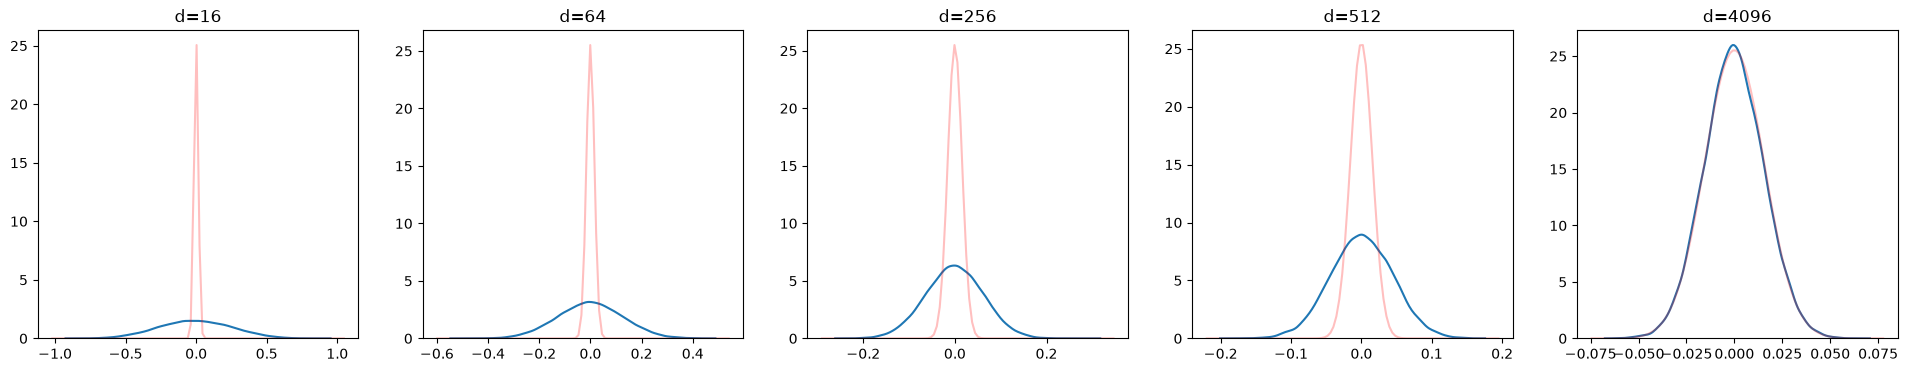

In [5]:
fig, axs = matplotlib.pyplot.subplots(ncols=len(D), figsize=(24, 4))

for iteration, s in enumerate(S):
    ax = seaborn.kdeplot(s, ax=axs[iteration])

    x0, x1 = ax.get_xlim()
    x_pdf = numpy.linspace(x0, x1, 100)
    y_pdf = scipy.stats.norm.pdf(x_pdf, 0.0, numpy.sqrt(1.0/d))
    
    ax.plot(x_pdf, y_pdf, 'red', alpha=0.25)
    ax.set_ylabel("")
    ax.set_title(f"d={D[iteration]}")

In [6]:
theoretical_variance = []
practical_mean = []
practical_variance = []

for iteration, d in enumerate(D):
    s = S[iteration]
    tv = 1.0/d
    pm = s.sum() / M
    pv = ((s - pm)**2).sum() / M

    theoretical_variance.append(tv)
    practical_mean.append(pm)
    practical_variance.append(pv)

In [7]:
pandas.DataFrame({
    "d": D,
    "theoretical_variance": theoretical_variance,
    "practical_mean": practical_mean,
    "practical_variance": practical_variance,
})

,d,theoretical_variance,practical_mean,practical_variance
0,16,0.062500,-0.005532,0.063058
1,64,0.015625,-0.000730,0.015873
2,256,0.003906,-0.000911,0.003905
3,512,0.001953,0.000423,0.001958
4,4096,0.000244,-0.000179,0.000242


### Задание 1.2. Смотрим на паразитный конус в модели EleutherAI/pythia-70m

In [8]:
import torch
from transformers import GPTNeoXForCausalLM, AutoTokenizer

In [18]:
tokenizer = AutoTokenizer.from_pretrained(
    "EleutherAI/pythia-70m",
     cache_dir="./pythia-70m-deduped",
)

model = GPTNeoXForCausalLM.from_pretrained(
    "EleutherAI/pythia-70m",
    torch_dtype=torch.float32,
    cache_dir="./pythia-70m-deduped",
)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [19]:
inputs = tokenizer("Hi, I am", return_tensors="pt")
tokens = model.generate(**inputs, max_new_tokens=64)
tokenizer.decode(tokens[0])

'Hi, I am a newbie to the community. I have been working on a project for a long time and I have been working on a project for a while now. I have been working on a project for a while now and I have been working on a project for a while now. I have been working on a project for a'

In [20]:
W = model.gpt_neox.embed_in.weight.detach().float().cpu()[:50_277]
count, d = W.shape
W.size()

torch.Size([50277, 512])

In [21]:
W_norm = torch.nn.functional.normalize(W, dim=1)
print(torch.linalg.norm(W[0]))
print(torch.linalg.norm(W_norm[0]))

tensor(0.5967)
tensor(1.0000)


In [22]:
n = 10_000

generator = torch.Generator().manual_seed(42)

idx1 = torch.randint(low=0, high=count, size=(n,), generator=generator)
idx2 = torch.randint(low=0, high=count, size=(n,), generator=generator)

same = idx1 == idx2
while same.any():
    idx2[same] = torch.randint(
        low=0,
        high=count,
        size=(same.sum().item(),),
        generator=generator,
    )
    same = idx1 == idx2

W1 = W_norm[idx1]
W2 = W_norm[idx2]
W1.size(), W2.size()

(torch.Size([10000, 512]), torch.Size([10000, 512]))

In [23]:
D = (W1 * W2).sum(dim=1).numpy()
D.mean(), D.std()

(np.float32(0.0040230844), np.float32(0.052762516))

Text(0.5, 1.0, 'd=512')

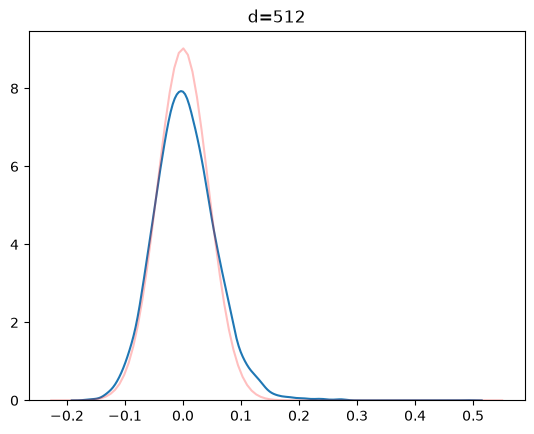

In [24]:
ax = seaborn.kdeplot(D)

x0, x1 = ax.get_xlim()

x_pdf = numpy.linspace(x0, x1, 100)
y_pdf = scipy.stats.norm.pdf(x_pdf, 0.0, numpy.sqrt(1.0/d))

ax.plot(x_pdf, y_pdf, 'red', alpha=0.25)
ax.set_ylabel("")
ax.set_title(f"d={d}")

## Задание 2

### Задание 2.1.

### Задание 2.2.

### Задание 2.3.

### Задание 2.4.